In [ ]:
#Generate prediction comparison b/w 99th percentile, 2 week percentile, perfect forecasting, 

import pandas as pd 
import numpy as np

#Get actual data/ draw values

#Predict 12 node values using 2-node prediction, compare with 2 week draw and percentile draw
node_12 = pd.read_csv(f"constant_setpoint_90023\\output_site_90023_51_5.56_12.csv")



,Hot Water Outlet Temperature (C),T_WH3,T_WH10,T_AMB,Water Heating Mode,Water Heating Electric Power,Draw Data,Setpoint
0,50.345948,50.400594,50.400594,20.0,Off,0.00025,0.00000,51.0
1,50.335961,50.353505,50.353673,20.0,Off,0.00025,0.00000,51.0
2,50.229827,50.305427,50.306805,20.0,Off,0.00025,0.00000,51.0
3,50.124866,50.257477,50.259982,20.0,Off,0.00025,0.00000,51.0
4,50.186351,50.186351,50.213195,20.0,Off,0.00025,3.78541,51.0
...,...,...,...,...,...,...,...,...
4314,50.237623,50.254412,49.806262,20.0,Off,0.00025,0.00000,51.0
4315,50.131864,50.206483,49.703050,20.0,Off,0.00025,0.00000,51.0
4316,50.027272,50.158663,49.598544,20.0,Off,0.00025,0.00000,51.0
4317,50.079363,50.079363,49.492900,20.0,Off,0.00025,0.00000,51.0


In [15]:
#2 node simulation
import os
import datetime as dt
import pandas as pd
import numpy as np

from ochre import Dwelling
from ochre.utils import default_input_path  # for using sample files
from ochre import HeatPumpWaterHeater

import datetime as dt
start_date = dt.datetime(2013, 2, 5, 0, 0) 
setpoint_default = 51  # in C #alternate b/w 60 and 49
deadband_default = 5.56  # in C

def predict_two_node(temp_n1, temp_n2, setpoint, draw):
    setpoint_default = setpoint
    equipment_args = {
        "start_time": start_date,  # year, month, day, hour, minute
        "time_res": dt.timedelta(minutes=1),
        "duration": dt.timedelta(minutes = len(draw)),
        "verbosity": 9,  # required to get setpoint and deadband in results
        "save_results": False,  # if True, must specify output_path
        # "output_path": os.getcwd(),        # Equipment parameters
        "Setpoint Temperature (C)": setpoint_default,
        "Tank Volume (L)": 250,
        "Tank Height (m)": 1.22,
        "UA (W/K)": 2.17,
        "HPWH COP (-)": 4.5,
        "water_nodes": 2
    }

    # Create water draw schedule
    times = pd.date_range(
        equipment_args["start_time"],
        equipment_args["start_time"] + equipment_args["duration"],
        freq=equipment_args["time_res"],
        inclusive="left",
    )
    #withdraw_rate = np.random.choice([0, water_draw_magnitude], p=[0.99, 0.01], size=len(times))
    withdraw_rate = draw
    withdraw_rate = withdraw_rate[:len(times)]
    schedule = pd.DataFrame(
        {
            "Water Heating (L/min)": withdraw_rate,
            "Water Heating Setpoint (C)": setpoint_default,  # Setting so that it can reset
            "Water Heating Deadband (C)": deadband_default,  # Setting so that it can reset
            "Zone Temperature (C)": 20,
            "Zone Wet Bulb Temperature (C)": 15,  # Required for HPWH
            "Mains Temperature (C)": 7,
        },
        index=times,
    )

    # Initialize equipment
    hpwh = HeatPumpWaterHeater(schedule=schedule, **equipment_args)

    hpwh.model.states[:] = np.array([temp_n1, temp_n2])

    # Simulate
    data = pd.DataFrame()
    data = {'draw_data' :[], 'setpoint' :[]}
    control_signal = {}
    setpoints = []

    for t in hpwh.sim_times:
        # Change setpoint based on hour of day
        setpoint = setpoint_default
        control_signal = {
            "Setpoint": setpoint
        }

        setpoints.append(setpoint)
        # Run with controls
        _ = hpwh.update(control_signal=control_signal)

    
    df = hpwh.finalize()

    cols_to_save = [
        "Hot Water Outlet Temperature (C)",
        "T_WH1",
        "T_WH2"
    ]

    to_save = df.loc[:, cols_to_save]
    to_save = to_save[14::15] #Get every 15 minutes
    to_save = to_save[:-1]

    #return to_save
    return to_save["Hot Water Outlet Temperature (C)"]


In [19]:
#node_2_temps = predict_two_node(n1, n2, setpoint[0], draw)

test_index = 259393
two_week_minutes = 20160

#Get raw flow data 
raw_flow = pd.read_csv("..\\ochre\\defaults\\Input Files\\net_flow_90023.csv")
two_week_data = raw_flow[259393 - 20160: ] #Get 2 weeks before starting value
two_week_data["Flow"] = raw_flow[259393 - 20160: ]
raw_flow = raw_flow[259393:]
two_week_data.reset_index(drop=True)



C:\Users\janel\AppData\Local\Temp\ipykernel_28640\175117761.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  two_week_data["Flow"] = raw_flow[259393 - 20160: ]


,0.0,Flow
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
85003,0.0,0.0
85004,0.0,0.0
85005,0.0,0.0
85006,0.0,0.0


In [37]:
#interactable slider
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from ipywidgets import interact

def plot_prediction(days=0, hours=0):
    start_time = pd.to_datetime("2013-05-29 01:22:00") #Start of training data
    
    lower = 96 * days + 4 * hours
    upper = lower + 8
    data_range = np.arange(lower, upper)

    # convert time interval
    tick_indices = np.arange(lower, upper)
    tick_labels = pd.to_datetime(tick_indices * 15, unit="m").strftime("%H:%M")

    fig, ax1 = plt.subplots()

    # get predictions
    node_12_temps = node_12["Hot Water Outlet Temperature (C)"][lower:upper]
    n1 = node_12["T_WH3"][lower]
    n2 = node_12["T_WH10"][lower]
    setpoint = node_12["Setpoint"]
    draw = node_12["Draw Data"][lower:upper]
    out = np.zeros(len(draw) * 16,)
    out[::16] = draw

    # Try using raw draw instead
    out = raw_flow[lower*15:lower*15 + 120].to_numpy().flatten()

    node_2_temps = predict_two_node(n1, n2, setpoint[0], out).values
    node_2_temps = np.insert(node_2_temps, 0, node_12_temps.reset_index(drop=True)[0])

    current_time = start_time + pd.Timedelta(minutes=lower)
    nth_flow = get_nth_flow(current_time)
    node_2_99 = predict_two_node(n1, n2, setpoint[0], nth_flow)
    node_2_99 = np.insert(node_2_99, 0, node_12_temps.reset_index(drop=True)[0])

    rolling_flow = get_rolling_flow_avg(two_week_data[lower:lower + two_week_minutes], current_time)
    node_2_week = predict_two_node(n1, n2, setpoint[0], rolling_flow)
    node_2_week = np.insert(node_2_week, 0, node_12_temps.reset_index(drop=True)[0])

    # plotting
    ax1.plot(data_range, node_12_temps, label="12-Node Model", color="tab:red")
    ax1.plot(data_range, node_2_99, label="99th Percentile Forecasting", color="green")
    ax1.plot(data_range, node_2_week, label="2 Week Forecasting", color="orange", linestyle='dashed')
    ax1.plot(data_range, node_2_temps, label="2-Node Perfect Forecasting", color="purple", linestyle='dashdot')
    ax1.set_xlabel("Time of Day (HH:MM)")
    ax1.set_ylabel("Hot Water Outlet Temperature (°C)", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")

    ax1.set_xticks(tick_indices[::4])
    ax1.set_xticklabels(tick_labels[::4], rotation=45)
    ax1.set_title("Prediction Comparison")

    # secondary axis (Draw Data)
    ax2 = ax1.twinx()
    ax2.plot(data_range, node_12["Draw Data"][lower:upper],
             label="Draw Data", linestyle='dotted', color="tab:blue")
    ax2.set_ylabel("Draw Data (L)", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")
    ax2.set_ylim(0, 50)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    fig.tight_layout()
    plt.show()

# Create sliders: days (0–20), hours (0–24)
interact(plot_prediction, days=(0, 20), hours=(0, 24, 1))


interactive(children=(IntSlider(value=0, description='days', max=20), IntSlider(value=0, description='hours', …

<function __main__.plot_prediction(days=0, hours=0)>

2025-09-19 12:27:06.526207 - Heat Pump Water Heater at 2013-02-05 00:00:00: Initializing Heat Pump Water Heater (OCHRE v0.8.5)
2025-09-19 12:27:06.546040 - Heat Pump Water Heater at 2013-02-05 02:00:00: Simulation complete, time series results saved in memory (not to a file)
2025-09-19 12:27:06.614603 - Heat Pump Water Heater at 2013-02-05 00:00:00: Initializing Heat Pump Water Heater (OCHRE v0.8.5)
2025-09-19 12:27:06.625273 - Heat Pump Water Heater at 2013-02-05 02:00:00: Simulation complete, time series results saved in memory (not to a file)
2025-09-19 12:27:06.685629 - Heat Pump Water Heater at 2013-02-05 00:00:00: Initializing Heat Pump Water Heater (OCHRE v0.8.5)
2025-09-19 12:27:06.706032 - Heat Pump Water Heater at 2013-02-05 02:00:00: Simulation complete, time series results saved in memory (not to a file)


C:\Users\janel\AppData\Local\Temp\ipykernel_28640\1463417330.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  two_weeks['readTime'] = pd.date_range(start=current_date, periods=len(two_weeks), freq="T")
C:\Users\janel\AppData\Local\Temp\ipykernel_28640\1463417330.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  two_weeks['readTime'] = pd.date_range(start=current_date, periods=len(two_weeks), freq="T")
C:\Users\janel\AppData\Local\Temp\ipykernel_28640\1463417330.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

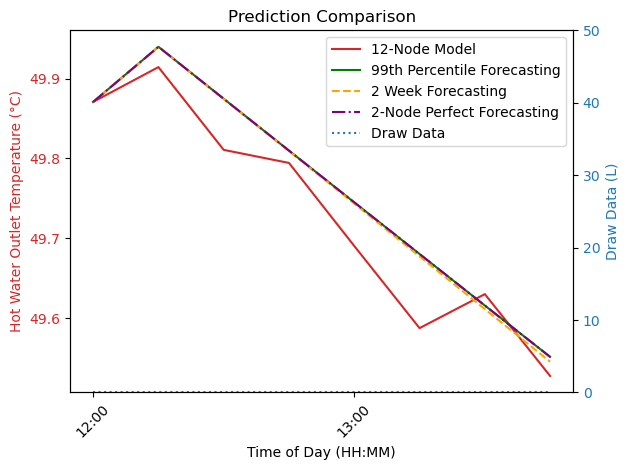

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

start_time = pd.to_datetime("2013-05-29 01:22:00") #Start of training data used for sim output


days = 15
hours = 12
lower =  96 * days + 4 * hours    # day value * 96
upper = lower + 8
data_range = np.arange(lower, upper)

# convert time interval
tick_indices = np.arange(lower, upper)  # all 96 intervals
# Map intervals to minutes of day (interval index * 15 min, modulo 1440 for wrapping)
tick_labels = pd.to_datetime(tick_indices * 15, unit="m").strftime("%H:%M")

fig, ax1 = plt.subplots()

#get predictions
node_12_temps = node_12["Hot Water Outlet Temperature (C)"][lower:upper]
n1 = node_12["T_WH3"][lower]
n2 = node_12["T_WH10"][lower]
setpoint = node_12["Setpoint"]
draw = node_12["Draw Data"][lower:upper]
out = np.zeros(len(draw) * 16,)
# Place elements every 16th spot
out[::16] = draw

#Try using raw draw instead
out = raw_flow[lower*15:lower*15 + 120].to_numpy().flatten()


node_2_temps = predict_two_node(n1, n2, setpoint[0], out) #n1, n2, setpoint, draw
node_2_temps = node_2_temps.values
node_2_temps = np.insert(node_2_temps, 0, node_12_temps.reset_index(drop=True)[0])

#Get percentiles
current_time = start_time + pd.Timedelta(minutes=lower)
nth_flow = get_nth_flow(current_time)
node_2_99 = predict_two_node(n1, n2, setpoint[0], nth_flow)
node_2_99 = np.insert(node_2_99, 0, node_12_temps.reset_index(drop=True)[0])

#Get rolling average

rolling_flow = get_rolling_flow_avg(two_week_data[lower:lower + two_week_minutes], current_time)
node_2_week = predict_two_node(n1, n2, setpoint[0], rolling_flow)
node_2_week = np.insert(node_2_week, 0, node_12_temps.reset_index(drop=True)[0])

# primary axis (temperature)
ax1.plot(
    data_range,
    node_12_temps,
    label="12-Node Model",
    color="tab:red"
)

ax1.plot(data_range, node_2_99, label="99th Percentile Forecasting", color="green")
ax1.plot(data_range, node_2_week, label="2 Week Forecasting",color="orange", linestyle='dashed')
ax1.plot(data_range, node_2_temps, label="2-Node Perfect Forecasting", color="purple", linestyle='dashdot')
ax1.set_xlabel("Time of Day (HH:MM)")
ax1.set_ylabel("Hot Water Outlet Temperature (°C)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax1.set_xticks(tick_indices[::4])
ax1.set_xticklabels(tick_labels[::4], rotation=45)
ax1.set_title("Prediction Comparison")

# secondary axis (Draw Data)
ax2 = ax1.twinx()
ax2.plot(
    data_range,
    node_12["Draw Data"][lower:upper],
    label="Draw Data",linestyle='dotted',
    color="tab:blue"
)
ax2.set_ylabel("Draw Data (L)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax2.set_ylim(0, 50)

# legends combined from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.tight_layout()
plt.show()


In [ ]:
two_weeks["hour"] = two_weeks["readTime"].dt.hour
two_weeks

,0.0,readTime,is_weekend,hour
240621,0.0,2013-05-29 01:22:00,False,1
240622,0.0,2013-05-29 01:23:00,False,1
240623,0.0,2013-05-29 01:24:00,False,1
240624,0.0,2013-05-29 01:25:00,False,1
240625,0.0,2013-05-29 01:26:00,False,1
...,...,...,...,...
260776,0.0,2013-06-12 01:17:00,False,1
260777,0.0,2013-06-12 01:18:00,False,1
260778,0.0,2013-06-12 01:19:00,False,1
260779,0.0,2013-06-12 01:20:00,False,1


In [17]:
def get_rolling_flow_avg(data, current_date, horizon = 2):# needs to receive previous two weeks of flow data, data should contain previous flow
    # Select current 2-week slice
    day_minutes = 60 * 24
    hour = current_date.hour
    minute = current_date.minute
    is_weekend = current_date.weekday() >= 5 #if is weekend

    two_weeks = data[:day_minutes * 14]
    two_weeks['readTime'] = pd.date_range(start=current_date, periods=len(two_weeks), freq="T")
    two_weeks["is_weekend"] = two_weeks["readTime"].dt.weekday >= 5
    two_weeks["hour"] = two_weeks["readTime"].dt.hour
    two_weeks = two_weeks.groupby(['hour', 'is_weekend'])['Flow'].mean().reset_index()

    predicted_flow = []
    h_offset = 0
    for i in range(horizon * 60):  # per-minute intervals in number of hours
            total_minutes = minute + i
            h_offset = total_minutes // 60
            current_hour = (hour + h_offset) % 24

            flow = two_weeks.loc[
                (two_weeks['hour'] == current_hour) &
                (two_weeks['is_weekend'] == is_weekend),
                'Flow'
            ]

            if not flow.empty:
                predicted_flow.append(flow.iloc[0] / 60)  # convert hourly flow to per-minute
            else:
                predicted_flow.append(0)  # or np.nan

    return predicted_flow

#get ninety-ninth percentile
raw_data = pd.read_csv("90023_raw.csv")
raw_data["readTime"] = pd.to_datetime(raw_data["readTime"])
raw_data = raw_data[raw_data["readTime"] > pd.Timestamp("2013-01-01")]
nth_percentile = 99 

# Convert flow to liters
raw_data["Flow"] = raw_data["Flow"] * 3.78541

interval = int(len(raw_data)*0.8)
train = raw_data[0:interval] 
train["isWeekend"] = train["readTime"].dt.weekday >= 5 #separate out df by weekends

#compute 99th percentile
train = train[["Flow", "hour", "isWeekend"]]
percentile = train.groupby(['hour', 'isWeekend'])['Flow'].quantile(nth_percentile*0.01).reset_index()

def get_nth_flow(timeStamp, horizon=2, percentiles = percentile):
    #Given a timeStamp, compute predicted flow data for horizon
    hour = timeStamp.hour
    is_weekend = timeStamp.weekday() >= 5
    minute = timeStamp.minute

    predicted_flow = []
    h_offset = 0
    for i in range(horizon * 60):  # loop minute-by-minute for the horizon
        # Update hour offset if minutes overflow
        total_minutes = minute + i
        h_offset = total_minutes // 60
        current_minute = total_minutes % 60

        flow = percentiles.loc[
            (percentiles['hour'] == (hour + h_offset) % 24) &
            (percentiles['isWeekend'] == is_weekend),
            'Flow'
        ]

        if not flow.empty:
            predicted_flow.append(flow.iloc[0] / 60)  # divide hourly flow into per-minute value
        else:
            predicted_flow.append(0)  # or np.nan

    return predicted_flow



C:\Users\janel\AppData\Local\Temp\ipykernel_28640\1463417330.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["isWeekend"] = train["readTime"].dt.weekday >= 5 #separate out df by weekends


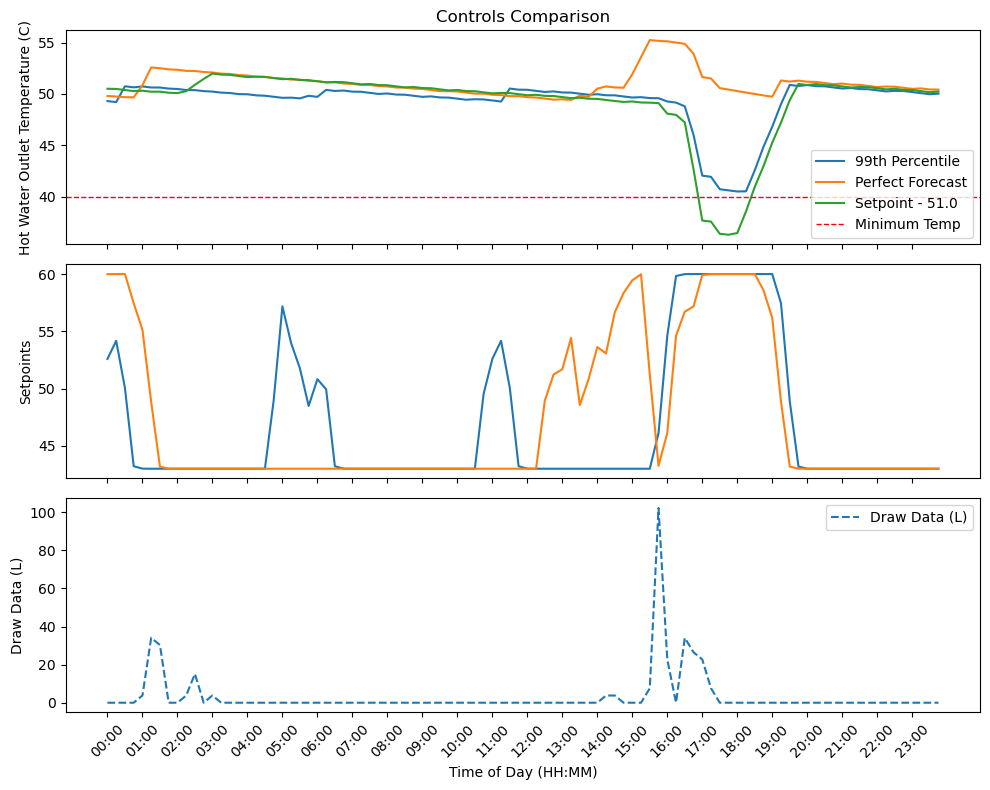

C:\Users\janel\AppData\Local\Temp\ipykernel_2288\1816969234.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


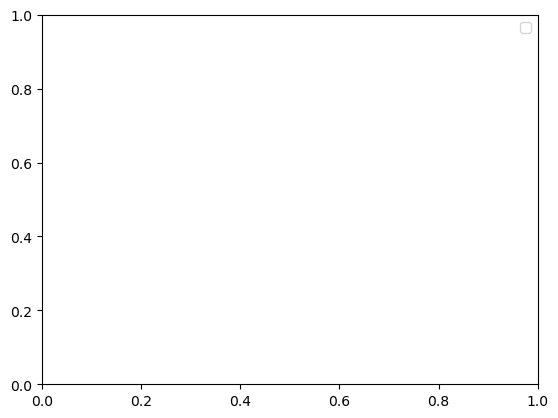

In [12]:
# look at index 1510 - 1520
site_number = 90023
water_nodes = 12
setpoint_temp = 51.0
bisection_temp = 49



data_control = pd.read_csv(f'constant_setpoint_90023\\output_site_90023_51_5.56_12.csv')
data_percentile = pd.read_csv(f'output_site_90023_bisectioncontrol_ud_{bisection_temp}_12_99_percentile.csv')
data_rolling = pd.read_csv(f'output_site_90023_bisectioncontrol_ud_{bisection_temp}_12_rolling avg.csv')
data_perfect = pd.read_csv(f"output_site_90023_bisectioncontrol_ud_{bisection_temp}_12_perfect.csv")
lower = (96) * 15 #day value * 96
upper = lower + 96
data_range = np.arange(lower, upper)

#convert time interval
tick_indices = np.arange(lower, upper)  # all 96 intervals
# Map intervals to minutes of day (interval index * 15 min, modulo 1440 for wrapping)
tick_minutes = ((tick_indices - lower) * 15) % 1440
tick_labels = pd.to_datetime(tick_minutes, unit="m").strftime("%H:%M")

fig, (ax3, ax1, ax2) = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

#---- Temperature ---
display_value = "Hot Water Outlet Temperature (C)"
ax3.set_title("Controls Comparison")
ax3.set_xticks(tick_indices[::4],)
ax3.set_xticklabels(tick_labels[::4], rotation=45)
ax3.set_ylabel(display_value)
ax3.plot(data_range, data_percentile[display_value][lower:upper], label="99th Percentile")
#ax3.plot(data_range, data_rolling[display_value][lower:upper], label="Rolling Avg")
ax3.plot(data_range, data_perfect[display_value][lower:upper], label="Perfect Forecast")
ax3.plot(data_range, data_control[display_value][lower:upper], label=f"Setpoint - {setpoint_temp}")
ax3.axhline(y=40, color='r', linestyle='--', linewidth=1, label='Minimum Temp')
ax3.legend(loc="lower right")

# ---- Top plot (Water Heating Electric Power) Change to setpoint----
display_value = "Setpoints"

ax1.set_xticks(tick_indices[::4],)
ax1.set_xticklabels(tick_labels[::4], rotation=45)

#ax1.set_ylabel("Water Heating Electric Power (kWh)")
ax1.set_ylabel("Setpoints")

ax1.plot(data_range, data_percentile[display_value][lower:upper], label="99th Percentile")
#ax1.plot(data_range, data_rolling[display_value][lower:upper], label="Rolling Avg")
ax1.plot(data_range, data_perfect[display_value][lower:upper], label="Perfect Forecast")
#ax1.plot(data_range, data_control[display_value][lower:upper], label=f"Setpoint - {setpoint_temp}")



# ---- Bottom plot (Draw Data) ----
ax2.plot(
    data_range,
    data_control['Draw Data'][lower:upper],
    label="Draw Data (L)",
    linestyle="--",
    color="tab:blue"
)

ax2.set_ylabel("Draw Data (L)")
ax2.set_xlabel("Time of Day (HH:MM)")
ax2.set_xticklabels(tick_labels[::4], rotation=45)
ax2.legend(loc="upper right")

# Adjust layout
plt.tight_layout()

plt.show()



plt.legend()

In [ ]:
import pandas as pd
import numpy as np

def get_daily_kWh(data):
    energy = data["Water Heating Electric Power"] #15 minute intervals of kwh
    day_sums = energy.groupby(energy.index // 96).sum().tolist()
    return (np.mean(day_sums))

def return_unmet_draws(data, min = 40.6):
    #data["Hot Water Outlet Temperature (C)"] = (pd.to_numeric(data["Hot Water Outlet Temperature (C)"], errors="coerce"))
    draws = data["Hot Water Outlet Temperature (C)"].values
    cold_water_draws = sum(float(i) < min for i in draws)
    return cold_water_draws/len(draws) * 100

# sites = [90159, 22096, 13438, 11531, 23744,
# 11289,
# 13265,
# 23666,
# 90028,
# 90050,
# 90135,
# 10441,
# 90015,
# 90030
# ]

sites = [21578, 22897, 90023, 90130, 99094, 90051, 90069, 90131, 90034]
sites = [99148, 99162, 99103, 99092, 99084] 


sites = [90159, 22096, 13438, 11531, 23744,
11289,
13265,
23666,
90028,
90050,
90135,
10441,
90015,
90030, 21578, 22897, 90023, 90130, 99094, 90051, 90069, 90131, 90034, 99148, 99162, 99103, 99092, 99084
]

unmet_draws = []
daily_kWh = []
net_savings = []
avg_draw = []
for site_number in sites:
    print(site_number)
    #Comparing standard performance to 40 G bisection controller

    min_temp = 40.6
    baseline_40 = pd.read_csv(f'output_site_{site_number}_151(L)_51.csv')
    elevated = pd.read_csv(f'output_site_{site_number}_151(L)_60.csv')

    files = [
        f'output_site_{site_number}_227(L)_51.csv',
        f'output_site_{site_number}_303(L)_51.csv',
        f'output_site_{site_number}_189(L)_51.csv'
    ]

    baseline_og = None

    for file in files:
        try:
            baseline_og = pd.read_csv(file)
            print("Loaded:", file)
            break
        except FileNotFoundError:
            pass

    if baseline_og is None:
        raise FileNotFoundError("None of the baseline files exist.")

 
    bisection = pd.read_csv(f"output_site_{site_number}_bisectioncontrol_ud_49_12_rolling avg.csv")
    #bisection_ideal = pd.read_csv(f"output_site_{site_number}_bisectioncontrol_ud_49_12_perfect.csv")


    print("Baseline (OG) ", return_unmet_draws(baseline_og, min_temp), get_daily_kWh(baseline_og), np.sum(baseline_og["Water Heating Electric Power"])) #365 days
    print("Baseline (40g): ", return_unmet_draws(baseline_40, min_temp), get_daily_kWh(baseline_40), np.sum(baseline_40["Water Heating Electric Power"])) #365 days
    print("Bisection", return_unmet_draws(bisection, min_temp), get_daily_kWh(bisection), np.sum(bisection["Water Heating Electric Power"])) #100 days
    print("Baseline (Elevated) ", return_unmet_draws(elevated, min_temp), get_daily_kWh(elevated), np.sum(elevated["Water Heating Electric Power"])) #365 days
    print("Net savings: ", 1 - np.sum(bisection["Water Heating Electric Power"])/np.sum(elevated["Water Heating Electric Power"]))

    draw = baseline_og['Draw Data']
    draw = draw[:-95] #removing last day to keep indices exact
    daily_avg = np.sum(np.asarray(draw).reshape(-1, 96), axis=1)
    avg_draw.append(daily_avg.mean()) #avg L per day
    unmet_draws.append([return_unmet_draws(baseline_og, min_temp),return_unmet_draws(baseline_40, min_temp),return_unmet_draws(elevated, min_temp), return_unmet_draws(bisection, min_temp) ])
    daily_kWh.append([get_daily_kWh(baseline_og), get_daily_kWh(baseline_40), get_daily_kWh(elevated),get_daily_kWh(bisection)  ])
    net_savings.append((1 - np.sum(bisection["Water Heating Electric Power"])/np.sum(elevated["Water Heating Electric Power"])) * 100)
    #print(return_unmet_draws(bisection_ideal, min_temp), get_daily_kWh(bisection_ideal), np.sum(bisection_ideal["Water Heating Electric Power"])) #100 days
 

99148
Baseline (OG)  0.0 1.4784655919607683 147.84655919607684
Baseline (40g):  0.07292426294405667 1.4663608221699855 146.6360822169985
Bisection 0.0 1.5028997822664776 150.28997822664772
Baseline (Elevated)  0.0 1.7482013427078689 174.82013427078687
Net savings:  0.14031653817484935
99162
Baseline (OG)  0.2708615480779248 1.5530427579699568 155.30427579699563
Baseline (40g):  0.677153870194812 1.5319032516311535 153.19032516311535
Bisection 0.0 1.5886325873175933 158.8632587317593
Baseline (Elevated)  0.03125325554745286 1.8334975200458015 183.34975200458015
Net savings:  0.13355073025792352
99103
Baseline (OG)  0.0 1.3412683065337194 134.1268306533719
Baseline (40g):  0.05208875924575477 1.3317377748371584 133.17377748371584
Bisection 0.0 1.358630789543631 135.86307895436306
Baseline (Elevated)  0.0 1.6084481732567335 160.8448173256733
Net savings:  0.15531578068025675
99092
99103
Baseline (OG)  0.0 1.3412683065337194 134.1268306533719
Baseline (40g):  0.05208875924575477 1.33173777

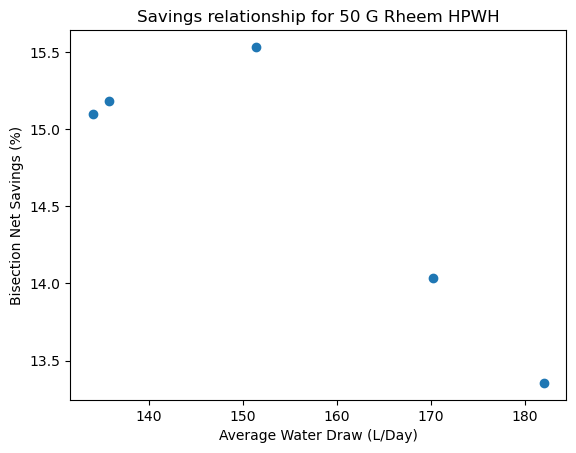

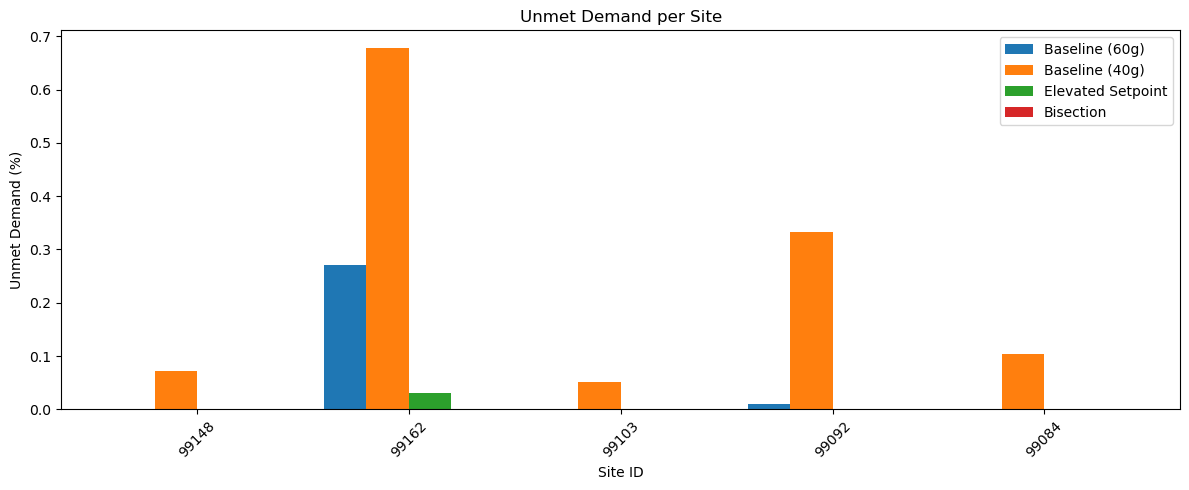

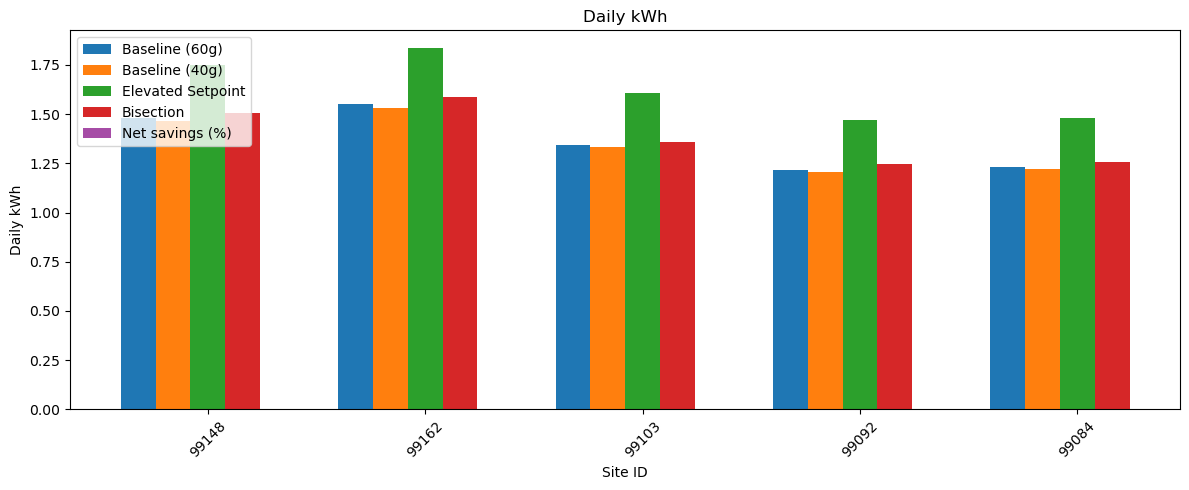

In [118]:
#Begin doing time series analysis
import matplotlib.pyplot as plt
import numpy as np


#scatter plot b/w net savings and daily L/day
plt.scatter(avg_draw, net_savings)
plt.xlabel("Average Water Draw (L/Day)")
plt.ylabel("Bisection Net Savings (%)") #Compared to elevated setpoint
plt.title("Savings relationship for 50 G Rheem HPWH")

import matplotlib.pyplot as plt
import numpy as np

# --- Plot 1: unmet_draws (clustered bars per site) ---
arr = np.array(unmet_draws)
if arr.size == 0:
    raise ValueError("`unmet_draws` is empty; run the previous cell that populates it first.")
if arr.ndim == 1:
    arr = arr.reshape(-1, 1)

n_sites, n_values = arr.shape
x = np.arange(n_sites)               # site index positions
bar_width = 0.8 / max(1, n_values)   # width of each bar cluster
offset = (bar_width * (n_values - 1)) / 2

# Friendly default labels for the 4 expected columns; fall back if shape differs
default_labels = ["Baseline (60g)", "Baseline (40g)", "Elevated Setpoint", "Bisection"]
if n_values == len(default_labels):
    labels = default_labels
else:
    labels = [f"value {i}" for i in range(n_values)]

plt.figure(figsize=(12, 5))
for i in range(n_values):
    plt.bar(x + i * bar_width - offset, arr[:, i],
            width=bar_width,
            label=labels[i])

# X ticks correspond to each site
plt.xticks(x, sites, rotation=45)
plt.xlabel("Site ID")
plt.ylabel("Unmet Demand (%)")
plt.title("Unmet Demand per Site")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: daily_kWh (bars) + net_savings (%) as bars on secondary y-axis ---
# Convert daily_kWh and net_savings to arrays (robust handling of nested lists)
daily_arr = np.array(daily_kWh)
if daily_arr.size == 0:
    raise ValueError("`daily_kWh` is empty; run the previous cell that populates it first.")
if daily_arr.ndim == 1:
    daily_arr = daily_arr.reshape(-1, 1)

net = np.array(net_savings)
# net_savings may be a list of single-value lists (e.g., [[0.1],[0.2]]); flatten safely
if net.ndim > 1:
    net = net.reshape(len(net), -1)[:, 0]

# Ensure lengths match
if daily_arr.shape[0] != len(net):
    raise ValueError("Number of sites in `daily_kWh` and `net_savings` do not match")

# We'll create (n_daily_cols + 1) bars per cluster where the last bar is net savings (shown on ax2)
n_daily_cols = daily_arr.shape[1]
n_total = n_daily_cols + 1
bar_width2 = 0.8 / max(1, n_total)
offset2 = (bar_width2 * (n_total - 1)) / 2

fig, ax = plt.subplots(figsize=(12, 5))
# Plot daily kWh bars on primary axis
kWh_labels = ["Baseline (60g)", "Baseline (40g)", "Elevated Setpoint", "Bisection"]

for i in range(n_daily_cols):
    ax.bar(x + i * bar_width2 - offset2, daily_arr[:, i], width=bar_width2, label=kWh_labels[i])

# Secondary axis for net savings bars (percentage)
#ax2 = ax.twinx()
net_percent = net * 100.0
# Position net bars as the last bar in the cluster
net_positions = x + n_daily_cols * bar_width2 - offset2
#ax2.bar(net_positions, net_percent, width=bar_width2, color='purple', alpha=0.7, label='Net savings (%)')

# Labels and ticks
ax.set_xticks(x)
ax.set_xticklabels(sites, rotation=45)
ax.set_xlabel("Site ID")
ax.set_ylabel("Daily kWh")
#ax2.set_ylabel("Net savings (%)",color='purple')
#ax2.tick_params(axis='y', labelcolor='purple')
#ax2.set_ylim(0, 50)
ax.set_title("Daily kWh")

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
plt.show()


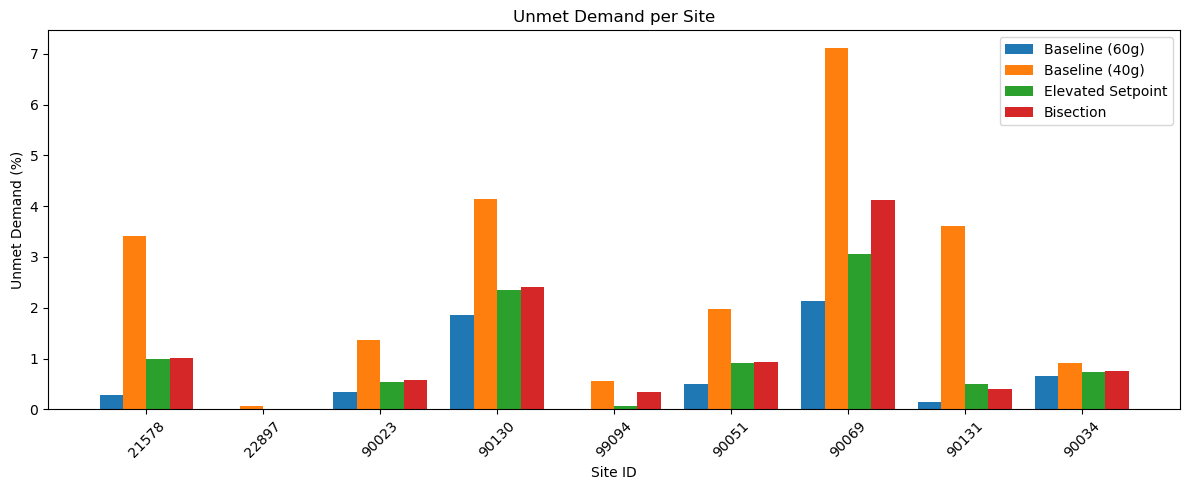

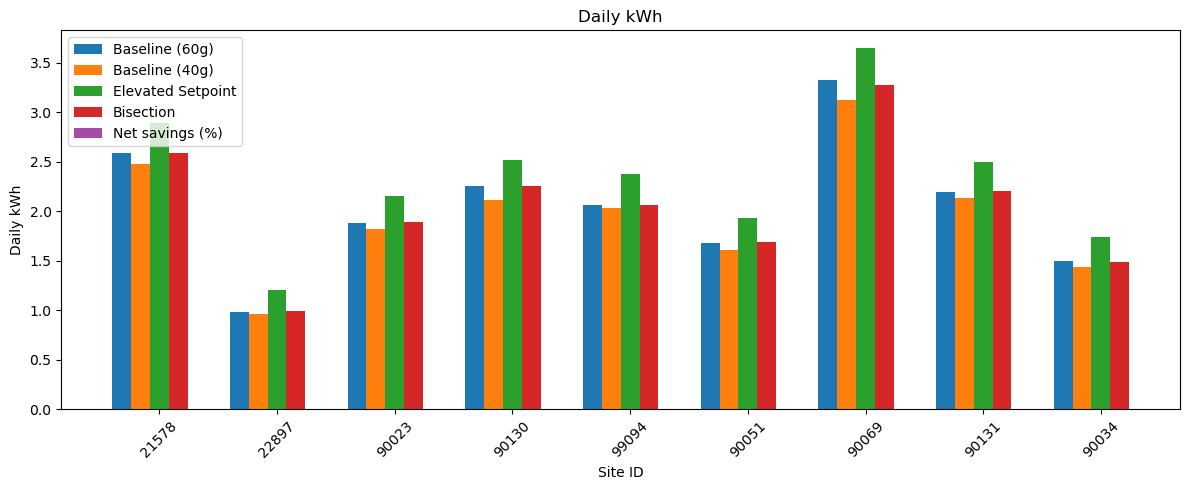

In [ ]:
#return_unmet_draws(baseline_og)
min = 40.6
data = baseline_og
draws = data["Hot Water Outlet Temperature (C)"].values
#cold_water_draws = sum(float(i) < min for i in draws)
new_draws = []
for i in draws:
    new_draws.append(float(i)
#cold_water_draws/len(draws) * 100


ValueError: could not convert string to float: 'Hot Water Outlet Temperature (C)'

1.525250731857181 3.7650959033862184
1.5241069414432529 3.8598152971820983
1.5564903808326624 0.5556841861542023


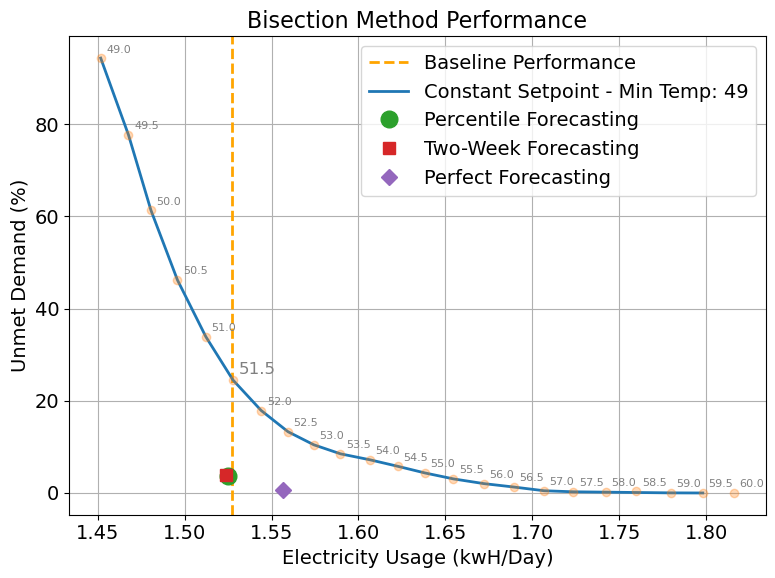

In [ ]:
def pareto_frontier(x_vals, y_vals):
    points = sorted(zip(x_vals, y_vals), key=lambda x: (x[0], x[1]))  # Sort by energy
    pareto_x, pareto_y = [], []
    min_y = float('inf')

    for x, y in points:
        if y < min_y:  # Keep only points with lower y than previously seen
            pareto_x.append(x)
            pareto_y.append(y)
            min_y = y
    return pareto_x, pareto_y


def get_daily_kWh(data):
    energy = data["Water Heating Electric Power"] #15 minute intervals of kwh
    day_sums = energy.groupby(energy.index // 96).sum().tolist()
    return (np.mean(day_sums))

def return_unmet_draws(data, min = 40.6):
    draws = data["Hot Water Outlet Temperature (C)"].values
    cold_water_draws = sum(float(i) < min for i in draws)
    return cold_water_draws/len(draws) * 100

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

site = "90023"
min_temp = 49 #Unmet demand cutoff
bisection_temp = 49
percent = pd.read_csv(f"bisection_output\\output_site_{site}_bisectioncontrol_ud_{bisection_temp}_12_99_percentile.csv")
weeks = pd.read_csv(f"bisection_output\\output_site_{site}_bisectioncontrol_ud_{bisection_temp}_12_rolling avg.csv")
control = pd.read_csv(f"bisection_output\\output_site_{site}_bisectioncontrol_ud_{bisection_temp}_12_perfect.csv")
constant = pd.read_csv(f"constant_setpoint_{site}\\output_site_{site}_51_5.56_12.csv")

# print(return_unmet_draws(percent, min_temp), get_daily_kWh(percent), np.sum(percent["Water Heating Electric Power"]))
# print(return_unmet_draws(weeks, min_temp),  get_daily_kWh(weeks), np.sum(percent["Water Heating Electric Power"]))
# print(return_unmet_draws(control, min_temp), get_daily_kWh(control), np.sum(control["Water Heating Electric Power"]))
# print(return_unmet_draws(constant, min_temp),  get_daily_kWh(constant), np.sum(constant["Water Heating Electric Power"]))

#pareto curve
min_setpoint = 49
max_setpoint = 60
setpoint_range = np.arange(min_setpoint , max_setpoint + 0.5, 0.5)
site_number = '90023'
water_nodes = 12
cold_water_gradient = []
net_energy_gradient = []
min_temps = [min_temp] #different unmet demand temperatures
for min_temp in min_temps:
    cold_water_draws = []
    net_energy = []
    for setpoint_default in setpoint_range: 
        withdraw_rate = pd.read_csv(f'constant_setpoint_90023\\output_site_{site_number}_{setpoint_default}_constant_setpoint_{water_nodes}.csv')


        cold = return_unmet_draws(withdraw_rate, min_temp)
        energy = withdraw_rate['Water Heating Electric Power']

        #sum 15 minute intervals into daily 
        daily_energy = []
        interval_length = 4 * 24 #4 intervals per hour
        daily_energy = get_daily_kWh(withdraw_rate)

        cold_water_draws.append(cold)
        
        net_energy.append(np.mean(daily_energy))
    cold_water_gradient .append(cold_water_draws)
    net_energy_gradient.append(net_energy)




# fig, ax1 = plt.subplots()

# # Primary y-axis (Unmet Demand %)
# ax1.plot(setpoint_range, cold_water_gradient, 'b-', label="Unmet Demand")
# ax1.set_xlabel("Setpoint (°C)")
# ax1.set_ylabel("Unmet Demand (%)", color='b')
# ax1.tick_params(axis='y', labelcolor='b')

# # Secondary y-axis (Energy in kWh)
# ax2 = ax1.twinx()
# ax2.plot(setpoint_range, net_energy, 'r-', label="Energy (kWh)")
# ax2.set_ylabel("Daily Energy (kWh)", color='r')
# ax2.tick_params(axis='y', labelcolor='r')

# # Optional: Add legends
# lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

# plt.title("Setpoint vs. Unmet Demand and Energy Use")
# plt.tight_layout()
# plt.show()


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.rcParams['font.size'] = 14  # Change 14 to your desired font size
for i in range(len(net_energy_gradient)):
    pareto_energy, pareto_demand = pareto_frontier(net_energy_gradient[i], cold_water_gradient[i])

    #plt.axvline(x=1.527, color='orange', linestyle='--', linewidth=2, label="Baseline Performance")
    # Plot the Pareto curve
    plt.plot(pareto_energy, pareto_demand, label=f"Constant Setpoint - Min Temp: {min_temps[i]}", linewidth=2)

    plt.plot(net_energy_gradient[i], cold_water_gradient[i], 'o', alpha=0.3)
    # Annotate each point with its setpoint
    for x, y, sp in zip(net_energy_gradient[i], cold_water_gradient[i], setpoint_range):
        if sp == 51.5:
            plt.annotate(f"{sp:.1f}", (x, y),
                    textcoords="offset points", xytext=(4, 4), ha='left', fontsize=12, color='gray')
        
        else:
            plt.annotate(f"{sp:.1f}", (x, y),
                    textcoords="offset points", xytext=(4, 4), ha='left', fontsize=8, color='gray')
        
    plt.plot(get_daily_kWh(percent), return_unmet_draws(percent, min_temps[i]),  'o', label=f"Percentile Forecasting", markersize=12) #I want to label each instance here with its setpoint fr/setpoint_range
    plt.plot(get_daily_kWh(weeks), return_unmet_draws(weeks, min_temps[i]),  's', label=f"Two-Week Forecasting", markersize=8)
    plt.plot(get_daily_kWh(control), return_unmet_draws(control, min_temps[i]),  'D', label=f"Perfect Forecasting", markersize=8)

    print(get_daily_kWh(percent), return_unmet_draws(percent, min_temps[i])) #I want to label each instance here with its setpoint fr/setpoint_range
    print(get_daily_kWh(weeks), return_unmet_draws(weeks, min_temps[i]))
    print(get_daily_kWh(control), return_unmet_draws(control, min_temps[i]))


#print(return_unmet_draws(percent), get_daily_kWh(percent), np.sum(percent["Water Heating Electric Power"]))
#print(return_unmet_draws(weeks),  get_daily_kWh(weeks), np.sum(percent["Water Heating Electric Power"]))
#print(return_unmet_draws(control), get_daily_kWh(control), np.sum(control["Water Heating Electric Power"]))
#print(return_unmet_draws(constant),  get_daily_kWh(constant), np.sum(constant["Water Heating Electric Power"]))

# Plot individual forecasting methods with markers


# Labels and formatting
plt.title("Bisection Method Performance", fontsize=16)
plt.ylabel("Unmet Demand (%)", fontsize=14)
plt.xlabel("Electricity Usage (kwH/Day)", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()

#plt.xlim(1.5, 1.57)
#plt.ylim(0, 10)
plt.show()


#plt.plot(setpoint_range, net_energy)
#plt.plot(setpoint_range, cold_water_draws)

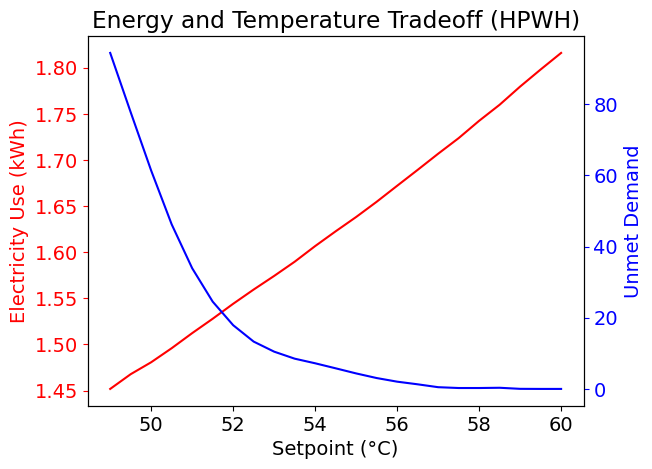

In [33]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Left y-axis: Electricity use (orange)
ax1.plot(setpoint_range, net_energy, color="red", label="Electricity Use (kWh)")
ax1.set_xlabel("Setpoint (°C)")
ax1.set_ylabel("Electricity Use (kWh)", color="red")
ax1.tick_params(axis='y', colors='red')

# Right y-axis: Unmet demand (blue)
ax2 = ax1.twinx()
ax2.plot(setpoint_range, cold_water_draws, color="blue", label="Unmet Demand")
ax2.set_ylabel("Unmet Demand", color="blue")
ax2.tick_params(axis='y', colors='blue')

# Title
plt.title("Energy and Temperature Tradeoff (HPWH)")

plt.show()


In [23]:
net_energy

[1.4517700395231508,
 1.4677468428414184,
 1.4807011108248245,
 1.4959132320125392,
 1.5122553481822978,
 1.527818856396974,
 1.5440651208533864,
 1.5595057097882052,
 1.5742700460245185,
 1.589651524253913,
 1.6066233799123313,
 1.6226276198742502,
 1.6381522857599562,
 1.654639597561314,
 1.6719907541251338,
 1.68922175934471,
 1.7067194814784397,
 1.7236291757297941,
 1.742425596278913,
 1.7598298727489745,
 1.7795280719590547,
 1.7980336869733466,
 1.8160201644479306]

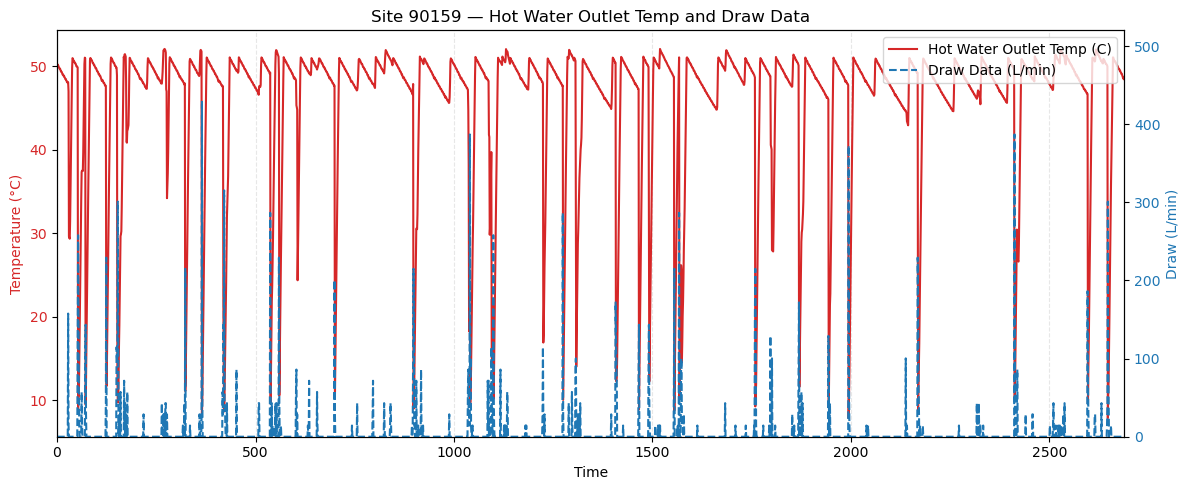

In [70]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load data for the selected site
site_number = 90159
baseline_40 = pd.read_csv(f'output_site_{site_number}_151(L)_12.csv')
elevated = pd.read_csv(f'output_site_{site_number}_151(L)_60.csv')
baseline_og = pd.read_csv(f'output_site_{site_number}_227(L)_12.csv')
bisection = pd.read_csv(f"output_site_{site_number}_bisectioncontrol_ud_49_12_rolling avg.csv")

# Series to plot
hot = baseline_40["Hot Water Outlet Temperature (C)"]
draw = baseline_40["Draw Data"]
# x-axis (use index; if you have a datetime index replace this with the datetime column)
x = np.arange(len(draw))

# Create figure and dual axes
fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis: hot water temperature
color_hot = "tab:red"
ax1.plot(x, hot, color=color_hot, label="Hot Water Outlet Temp (C)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)", color=color_hot)
ax1.tick_params(axis='y', labelcolor=color_hot)
ax1.grid(True, which='both', axis='x', linestyle='--', alpha=0.3)

# Right axis: draw data
ax2 = ax1.twinx()
color_draw = "tab:blue"
ax2.plot(x, draw, color=color_draw, linestyle='--', label="Draw Data (L/min)")
ax2.set_ylabel("Draw (L/min)", color=color_draw)
ax2.tick_params(axis='y', labelcolor=color_draw)
# Set a sensible upper limit so the draw axis isn't squashed (guard against zero-length)
if len(draw) > 0:
    ax2.set_ylim(0, max(draw.max() * 1.1, 1))

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title(f"Site {site_number} — Hot Water Outlet Temp and Draw Data")
fig.tight_layout()
day = 6
plt.xlim(96 * (day - 1), 96 * day)
plt.xlim(0, 672 * 4)
plt.show()
# map full-scale tick po1day